In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('parkinsons.data.csv')

In [3]:
df.head()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [ ]:
X_features = [
    'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)',
    'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP',
    'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
    'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA',
    'spread1', 'spread2', 'D2', 'PPE'
]

y = 'satus'

# linear regression

--- Performance Metrics ---
Train R2:   0.5357
Test R2:    -2.3571
Train MSE:  0.2329
Test MSE:   0.2099
Train RMSE: 0.4826
Test RMSE:  0.4582


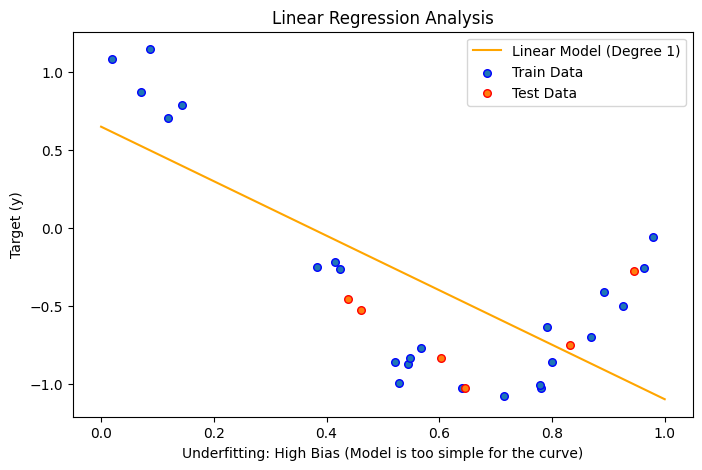

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 1. Generate Synthetic Data
np.random.seed(0)
n_samples = 30
X = np.sort(np.random.rand(n_samples))
y = np.cos(1.5 * np.pi * X) + np.random.randn(n_samples) * 0.1
X = X[:, np.newaxis]

# 2. Data Splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Linear Regression Model (Degree 1)
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# 5. Performance Metrics
train_mse_linear = mean_squared_error(y_train, y_train_pred)
test_mse_linear = mean_squared_error(y_test, y_test_pred)

train_rmse_linear = np.sqrt(train_mse_linear)
test_rmse_linear = np.sqrt(test_mse_linear)

train_r2_linear = r2_score(y_train, y_train_pred)
test_r2_linear = r2_score(y_test, y_test_pred)

# Print Metrics
print(f"--- Performance Metrics ---")
print(f"Train R2:   {train_r2_linear:.4f}")
print(f"Test R2:    {test_r2_linear:.4f}")
print(f"Train MSE:  {train_mse_linear:.4f}")
print(f"Test MSE:   {test_mse_linear:.4f}")
print(f"Train RMSE: {train_rmse_linear:.4f}")
print(f"Test RMSE:  {test_rmse_linear:.4f}")

# 6. Visualization
plt.figure(figsize=(8, 5))
X_plot = np.linspace(0, 1, 100)[:, np.newaxis]
y_plot = model.predict(X_plot)

plt.plot(X_plot, y_plot, color='orange', label="Linear Model (Degree 1)")
plt.scatter(X_train, y_train, edgecolor='b', s=30, label="Train Data")
plt.scatter(X_test, y_test, edgecolor='r', s=30, label="Test Data")

plt.title("Linear Regression Analysis")
plt.xlabel("Underfitting: High Bias (Model is too simple for the curve)")
plt.ylabel("Target (y)")
plt.legend()
plt.show()

# polynomial degree 2

--- Performance Metrics (Degree 2) ---
train_r2_linear (Poly D2): 0.9329
test_r2_linear (Poly D2):  0.7744
Train MSE:                0.0337
Test MSE:                 0.0141
Train RMSE:               0.1835
Test RMSE:                0.1188


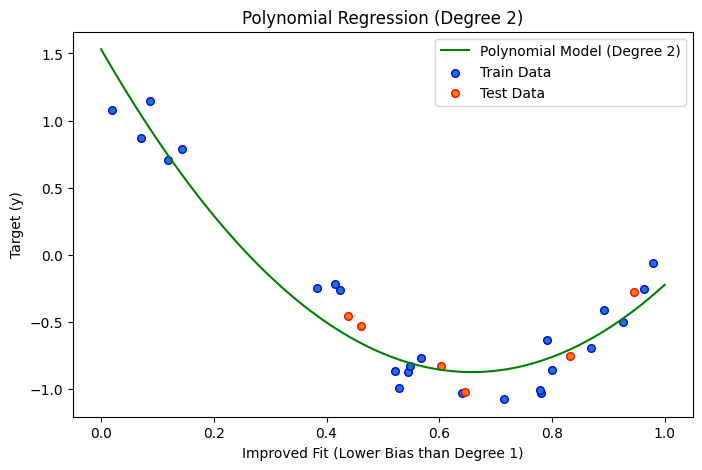

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 1. Generate Synthetic Data
np.random.seed(0)
n_samples = 30
X = np.sort(np.random.rand(n_samples))
y = np.cos(1.5 * np.pi * X) + np.random.randn(n_samples) * 0.1
X = X[:, np.newaxis]

# 2. Data Splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Polynomial Regression Model (Degree 2)
# We use a Pipeline to transform features to degree 2 and then run Linear Regression
degree = 2
model = Pipeline([
    ("poly_features", PolynomialFeatures(degree=degree, include_bias=False)),
    ("linear_regression", LinearRegression())
])

model.fit(X_train, y_train)

# 4. Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# 5. Performance Metrics
train_mse_poly2 = mean_squared_error(y_train, y_train_pred)
test_mse_poly2 = mean_squared_error(y_test, y_test_pred)

train_rmse_poly2 = np.sqrt(train_mse_poly2)
test_rmse_poly2 = np.sqrt(test_mse_poly2)

train_r2_poly2 = r2_score(y_train, y_train_pred)
test_r2_poly2 = r2_score(y_test, y_test_pred)

# Print Metrics
print(f"--- Performance Metrics (Degree {degree}) ---")
print(f"train_r2_linear (Poly D2): {train_r2_poly2:.4f}")
print(f"test_r2_linear (Poly D2):  {test_r2_poly2:.4f}")
print(f"Train MSE:                {train_mse_poly2:.4f}")
print(f"Test MSE:                 {test_mse_poly2:.4f}")
print(f"Train RMSE:               {train_rmse_poly2:.4f}")
print(f"Test RMSE:                {test_rmse_poly2:.4f}")

# 6. Visualization
plt.figure(figsize=(8, 5))
X_plot = np.linspace(0, 1, 100)[:, np.newaxis]
y_plot = model.predict(X_plot)

plt.plot(X_plot, y_plot, color='green', label=f"Polynomial Model (Degree {degree})")
plt.scatter(X_train, y_train, edgecolor='b', s=30, label="Train Data")
plt.scatter(X_test, y_test, edgecolor='r', s=30, label="Test Data")

plt.title(f"Polynomial Regression (Degree {degree})")
plt.xlabel("Improved Fit (Lower Bias than Degree 1)")
plt.ylabel("Target (y)")
plt.legend()
plt.show()

# polynomial with degree 3

--- Performance Metrics (Degree 3) ---
train_r2_linear (Poly D3): 0.9701
test_r2_linear (Poly D3):  0.9578
Train MSE:                0.0150
Test MSE:                 0.0026
Train RMSE:               0.1225
Test RMSE:                0.0514


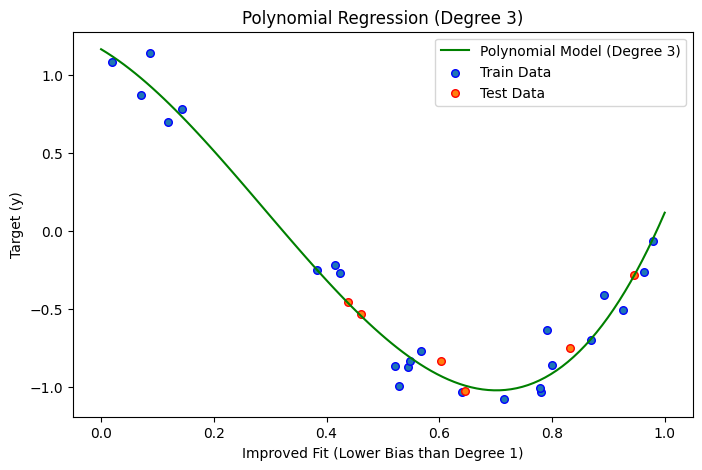

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 1. Generate Synthetic Data
np.random.seed(0)
n_samples = 30
X = np.sort(np.random.rand(n_samples))
y = np.cos(1.5 * np.pi * X) + np.random.randn(n_samples) * 0.1
X = X[:, np.newaxis]

# 2. Data Splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Polynomial Regression Model (Degree 3)

degree = 3
model = Pipeline([
    ("poly_features", PolynomialFeatures(degree=degree, include_bias=False)),
    ("linear_regression", LinearRegression())
])

model.fit(X_train, y_train)

# 4. Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# 5. Performance Metrics
train_mse_poly3 = mean_squared_error(y_train, y_train_pred)
test_mse_poly3 = mean_squared_error(y_test, y_test_pred)

train_rmse_poly3 = np.sqrt(train_mse_poly3)
test_rmse_poly3 = np.sqrt(test_mse_poly3)

train_r2_poly3 = r2_score(y_train, y_train_pred)
test_r2_poly3 = r2_score(y_test, y_test_pred)

# Print Metrics
print(f"--- Performance Metrics (Degree {degree}) ---")
print(f"train_r2_linear (Poly D3): {train_r2_poly3:.4f}")
print(f"test_r2_linear (Poly D3):  {test_r2_poly3:.4f}")
print(f"Train MSE:                {train_mse_poly3:.4f}")
print(f"Test MSE:                 {test_mse_poly3:.4f}")
print(f"Train RMSE:               {train_rmse_poly3:.4f}")
print(f"Test RMSE:                {test_rmse_poly3:.4f}")

# 6. Visualization
plt.figure(figsize=(8, 5))
X_plot = np.linspace(0, 1, 100)[:, np.newaxis]
y_plot = model.predict(X_plot)

plt.plot(X_plot, y_plot, color='green', label=f"Polynomial Model (Degree {degree})")
plt.scatter(X_train, y_train, edgecolor='b', s=30, label="Train Data")
plt.scatter(X_test, y_test, edgecolor='r', s=30, label="Test Data")

plt.title(f"Polynomial Regression (Degree {degree})")
plt.xlabel("Improved Fit (Lower Bias than Degree 1)")
plt.ylabel("Target (y)")
plt.legend()
plt.show()

# RANDOM FOREST

--- Performance Metrics (Random Forest) ---
train_r2_linear (RF): 0.9941
test_r2_linear (RF):  0.7644
Train MSE:            0.0030
Test MSE:             0.0147
Train RMSE:           0.0546
Test RMSE:            0.1214


C:\Users\Khalid\AppData\Local\Temp\ipykernel_17496\2997935636.py:52: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test, y_test, edgecolor='black', s=30, label="Test Data", marker='x')


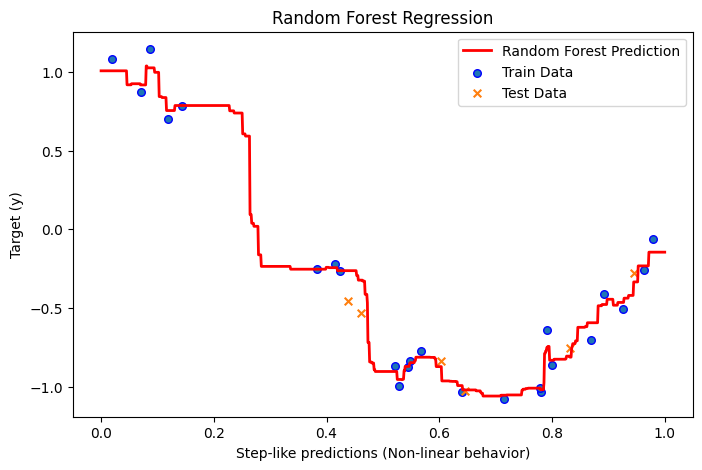

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 1. Generate Synthetic Data
np.random.seed(0)
n_samples = 30
X = np.sort(np.random.rand(n_samples))
y = np.cos(1.5 * np.pi * X) + np.random.randn(n_samples) * 0.1
X = X[:, np.newaxis]

# 2. Data Splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Random Forest Model
# We use a small number of estimators for this small dataset
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train.ravel())

# 4. Predictions
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# 5. Performance Metrics
train_mse_rf = mean_squared_error(y_train, y_train_pred)
test_mse_rf = mean_squared_error(y_test, y_test_pred)

train_rmse_rf = np.sqrt(train_mse_rf)
test_rmse_rf = np.sqrt(test_mse_rf)

train_r2_rf = r2_score(y_train, y_train_pred)
test_r2_rf = r2_score(y_test, y_test_pred)

# Print Metrics
print(f"--- Performance Metrics (Random Forest) ---")
print(f"train_r2_linear (RF): {train_r2_rf:.4f}")
print(f"test_r2_linear (RF):  {test_r2_rf:.4f}")
print(f"Train MSE:            {train_mse_rf:.4f}")
print(f"Test MSE:             {test_mse_rf:.4f}")
print(f"Train RMSE:           {train_rmse_rf:.4f}")
print(f"Test RMSE:            {test_rmse_rf:.4f}")

# 6. Visualization
plt.figure(figsize=(8, 5))
X_plot = np.linspace(0, 1, 1000)[:, np.newaxis]
y_plot = rf_model.predict(X_plot)

plt.plot(X_plot, y_plot, color='red', label="Random Forest Prediction", linewidth=2)
plt.scatter(X_train, y_train, edgecolor='b', s=30, label="Train Data")
plt.scatter(X_test, y_test, edgecolor='black', s=30, label="Test Data", marker='x')

plt.title("Random Forest Regression")
plt.xlabel("Step-like predictions (Non-linear behavior)")
plt.ylabel("Target (y)")
plt.legend()
plt.show()

# Comparision

In [27]:
comparision = pd.DataFrame({
    "Model": ["Linear Regression (Degree 1)", "Polynomial Regression (Degree 2)", "Polynomial Regression (Degree 3)", "Random Forest"],
    "Train R2": [train_r2_linear, train_r2_poly2, train_r2_poly3, train_r2_rf],
    "Test R2": [test_r2_linear, test_r2_poly2, test_r2_poly3, test_r2_rf],
    "Train MSE": [train_mse_linear, train_mse_poly2, train_mse_poly3, train_mse_rf],
    "Test MSE": [test_mse_linear, test_mse_poly2, test_mse_poly3, test_mse_rf],
    "Train RMSE": [train_rmse_linear, train_rmse_poly2, train_rmse_poly3, train_rmse_rf],
    "Test RMSE": [test_rmse_linear, test_rmse_poly2, test_rmse_poly3, test_rmse_rf]
})

comparision.sort_values(by="Test R2", ascending=False, inplace=True)
comparision

,Model,Train R2,Test R2,Train MSE,Test MSE,Train RMSE,Test RMSE
2,Polynomial Regression (Degree 3),0.970106,0.957790,0.014996,0.002640,0.122460,0.051377
1,Polynomial Regression (Degree 2),0.932851,0.774375,0.033685,0.014109,0.183534,0.118782
3,Random Forest,0.994051,0.764433,0.002984,0.014731,0.054630,0.121371
0,Linear Regression (Degree 1),0.535747,-2.357079,0.232890,0.209932,0.482586,0.458184
